# A/B Testing & Experimental Design

Topic 10 of the Statistical Inference & Hypothesis Testing repo. Topic 09 answered 'how many samples do I need' for an A/B test. This notebook covers what happens around that number: designing a proper randomized experiment, running the two-proportion test correctly, and — the real substance of this notebook — directly measuring two of the most common real-world ways A/B tests silently produce wrong conclusions: peeking at results before the planned sample size is reached, and undetected sample ratio mismatches in the randomization itself.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
from statsmodels.stats.power import NormalIndPower

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
print("Setup complete.")

Setup complete.


## 1. Randomization: the Foundation of a Valid Experiment

A/B testing's core promise is that random assignment makes the two groups comparable on *everything* (observed and unobserved), so any outcome difference can be attributed to the treatment. This section verifies that promise directly: randomly assigning a covariate-rich population to two groups and checking that the covariates end up balanced.

In [2]:
n_users = 4000
rng = np.random.default_rng(1)

users = pd.DataFrame({
    "user_id": np.arange(n_users),
    "prior_spend": rng.gamma(2, 50, size=n_users),
    "tenure_days": rng.exponential(200, size=n_users),
    "is_mobile": rng.binomial(1, 0.6, size=n_users),
})
print(f"{n_users} users generated with 3 covariates (prior_spend, tenure_days, is_mobile).")

4000 users generated with 3 covariates (prior_spend, tenure_days, is_mobile).


In [3]:
users["variant"] = rng.choice(["control", "treatment"], size=n_users, p=[0.5, 0.5])
print(f"{n_users} users randomly assigned to control/treatment.")
print(users["variant"].value_counts())

4000 users randomly assigned to control/treatment.
variant
treatment    2016
control      1984
Name: count, dtype: int64


In [4]:
balance_check = users.groupby("variant")[["prior_spend", "tenure_days", "is_mobile"]].mean()
print(balance_check.round(3))

for col in ["prior_spend", "tenure_days", "is_mobile"]:
    control_vals = users.loc[users["variant"] == "control", col]
    treatment_vals = users.loc[users["variant"] == "treatment", col]
    _, p = stats.ttest_ind(control_vals, treatment_vals)
    print(f"{col:15s}: control mean={control_vals.mean():.3f}, treatment mean={treatment_vals.mean():.3f}, "
          f"balance-check p={p:.3f} ({'balanced' if p > 0.05 else 'IMBALANCED -- investigate randomization'})")

           prior_spend  tenure_days  is_mobile
variant                                       
control         98.353      196.059      0.614
treatment       97.891      197.731      0.623
prior_spend    : control mean=98.353, treatment mean=97.891, balance-check p=0.833 (balanced)
tenure_days    : control mean=196.059, treatment mean=197.731, balance-check p=0.789 (balanced)
is_mobile      : control mean=0.614, treatment mean=0.623, balance-check p=0.598 (balanced)


## 2. Running the Core Test: Two-Proportion Z-Test

$$z = \frac{\hat{p}_1 - \hat{p}_2}{\sqrt{\hat{p}(1-\hat{p})(1/n_1 + 1/n_2)}}, \qquad \hat{p} = \frac{x_1+x_2}{n_1+n_2}$$

The standard test for comparing two conversion rates, using a pooled proportion under $H_0$. Built from scratch and validated against `statsmodels.stats.proportion.proportions_ztest`.

In [5]:
def two_proportion_ztest_scratch(x1, n1, x2, n2):
    p1, p2 = x1 / n1, x2 / n2
    p_pooled = (x1 + x2) / (n1 + n2)
    se = np.sqrt(p_pooled * (1 - p_pooled) * (1 / n1 + 1 / n2))
    z = (p1 - p2) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    return z, p_value

print("Two-proportion z-test function defined.")

Two-proportion z-test function defined.


In [6]:
# Simulate a real A/B test: control converts at 10%, treatment gets a genuine lift to 12%
rng_ab = np.random.default_rng(2)
n_per_variant = 3835  # the exact n Topic 09 calculated for 80% power at this effect size
control_conversions = rng_ab.binomial(n_per_variant, 0.10)
treatment_conversions = rng_ab.binomial(n_per_variant, 0.12)
print(f"Control: {control_conversions}/{n_per_variant}  |  Treatment: {treatment_conversions}/{n_per_variant}")

Control: 386/3835  |  Treatment: 459/3835


In [7]:
z_manual, p_manual = two_proportion_ztest_scratch(control_conversions, n_per_variant, treatment_conversions, n_per_variant)
z_scipy, p_scipy = proportions_ztest([treatment_conversions, control_conversions], [n_per_variant, n_per_variant])

print(f"Control: {control_conversions}/{n_per_variant} = {control_conversions/n_per_variant:.4f}")
print(f"Treatment: {treatment_conversions}/{n_per_variant} = {treatment_conversions/n_per_variant:.4f}")
print(f"Manual z: {z_manual:.6f}  |  statsmodels z: {z_scipy:.6f}")
print(f"Manual p: {p_manual:.6f}  |  statsmodels p: {p_scipy:.6f}")
assert abs(abs(z_manual) - abs(z_scipy)) < 1e-6
print("Manual two-proportion z-test matches statsmodels closely.")

Control: 386/3835 = 0.1007
Treatment: 459/3835 = 0.1197
Manual z: -2.662201  |  statsmodels z: 2.662201
Manual p: 0.007763  |  statsmodels p: 0.007763
Manual two-proportion z-test matches statsmodels closely.


In [8]:
print(f"H0: control and treatment conversion rates are equal")
print(f"p-value: {p_manual:.4f}  vs  alpha=0.05")
print(f"Decision: {'REJECT H0 -- treatment shows a significant lift' if p_manual < 0.05 else 'FAIL TO REJECT H0'}")

H0: control and treatment conversion rates are equal
p-value: 0.0078  vs  alpha=0.05
Decision: REJECT H0 -- treatment shows a significant lift


## 3. The Peeking Problem: Why Checking Significance Early Inflates False Positives

A common, tempting mistake: check the p-value every day as data accumulates, and stop the experiment the moment it dips below 0.05. This section simulates that exact behavior under a **true null** (no real difference between variants) and measures the actual false-positive rate.

In [9]:
def simulate_fixed_horizon_test(n_final, true_rate, n_repeats, alpha, rng):
    false_positives = 0
    for _ in range(n_repeats):
        control = rng.binomial(n_final, true_rate)
        treatment = rng.binomial(n_final, true_rate)  # SAME true rate -- H0 is true by construction
        _, p = proportions_ztest([treatment, control], [n_final, n_final])
        if p < alpha:
            false_positives += 1
    return false_positives / n_repeats

print("Fixed-horizon (check once, at the end) test simulator defined.")

Fixed-horizon (check once, at the end) test simulator defined.


In [10]:
def simulate_peeking_test(n_final, n_checks, true_rate, n_repeats, alpha, rng):
    false_positives = 0
    check_points = np.linspace(n_final / n_checks, n_final, n_checks).astype(int)
    for _ in range(n_repeats):
        control_stream = rng.binomial(1, true_rate, size=n_final)
        treatment_stream = rng.binomial(1, true_rate, size=n_final)  # SAME true rate -- H0 true throughout
        stopped_significant = False
        for checkpoint in check_points:
            c_sum, t_sum = control_stream[:checkpoint].sum(), treatment_stream[:checkpoint].sum()
            if c_sum == 0 or t_sum == 0:
                continue
            _, p = proportions_ztest([t_sum, c_sum], [checkpoint, checkpoint])
            if p < alpha:
                stopped_significant = True
                break
        if stopped_significant:
            false_positives += 1
    return false_positives / n_repeats

print("Peeking (check repeatedly, stop at first significance) test simulator defined.")

Peeking (check repeatedly, stop at first significance) test simulator defined.


In [11]:
n_final_test = 2000
true_rate_test = 0.10
n_repeats_peek = 3000
rng_fixed = np.random.default_rng(3)
rng_peek = np.random.default_rng(4)

fixed_horizon_rate = simulate_fixed_horizon_test(n_final_test, true_rate_test, n_repeats_peek, 0.05, rng_fixed)
peeking_rate_5 = simulate_peeking_test(n_final_test, 5, true_rate_test, n_repeats_peek, 0.05, rng_peek)

print(f"True Type I error rate, checking ONCE at the end (n={n_final_test}): {fixed_horizon_rate:.4f}")
print(f"True Type I error rate, checking 5 TIMES and stopping at first p<0.05: {peeking_rate_5:.4f}")
print(f"\nPeeking 5 times inflates the false-positive rate from the nominal 5% to "
      f"{peeking_rate_5*100:.1f}% -- a real, substantial increase in false 'winners' declared purely "
      f"from checking the data repeatedly, with NO real effect present.")

True Type I error rate, checking ONCE at the end (n=2000): 0.0430
True Type I error rate, checking 5 TIMES and stopping at first p<0.05: 0.1377

Peeking 5 times inflates the false-positive rate from the nominal 5% to 13.8% -- a real, substantial increase in false 'winners' declared purely from checking the data repeatedly, with NO real effect present.


In [12]:
n_checks_range = [1, 2, 5, 10, 20]
rng_peek_sweep = np.random.default_rng(5)
peek_sweep_rows = []
for n_checks in n_checks_range:
    rate = simulate_peeking_test(n_final_test, n_checks, true_rate_test, 2000, 0.05, rng_peek_sweep)
    peek_sweep_rows.append({"n_checks": n_checks, "empirical_false_positive_rate": round(rate, 4)})
peek_sweep_df = pd.DataFrame(peek_sweep_rows)
print(peek_sweep_df.to_string(index=False))

 n_checks  empirical_false_positive_rate
        1                         0.0540
        2                         0.0810
        5                         0.1350
       10                         0.1755
       20                         0.2395


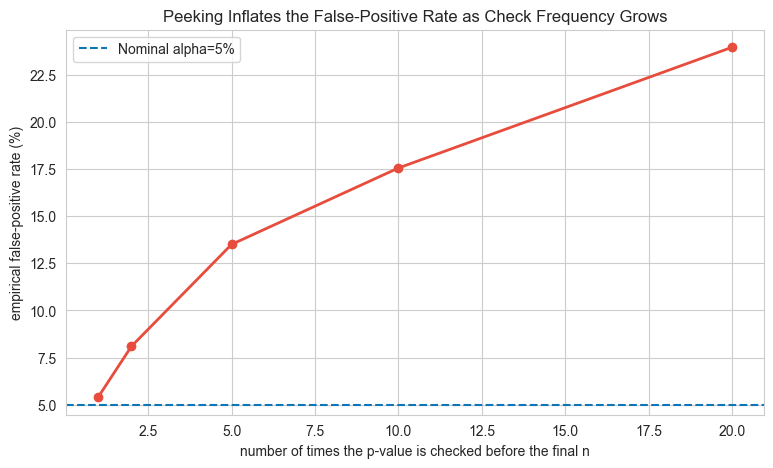

In [13]:
fig, ax = plt.subplots()
ax.plot(peek_sweep_df["n_checks"], peek_sweep_df["empirical_false_positive_rate"] * 100, marker="o", color="#e74c3c", linewidth=2)
ax.axhline(5, color="#0e75b6", linestyle="--", label="Nominal alpha=5%")
ax.set_xlabel("number of times the p-value is checked before the final n")
ax.set_ylabel("empirical false-positive rate (%)")
ax.set_title("Peeking Inflates the False-Positive Rate as Check Frequency Grows")
ax.legend()
plt.show()

## 4. Fixing Peeking: a Simple Alpha-Spending Correction

One straightforward (if conservative) fix: apply a Bonferroni-style correction, dividing alpha by the number of planned checks, so the *cumulative* false-positive rate across all checks stays near the nominal level — the same logic as Topic 06's Tukey/Bonferroni post-hoc corrections, applied across time instead of across groups.

In [14]:
def simulate_peeking_test_corrected(n_final, n_checks, true_rate, n_repeats, alpha, rng):
    corrected_alpha = alpha / n_checks
    false_positives = 0
    check_points = np.linspace(n_final / n_checks, n_final, n_checks).astype(int)
    for _ in range(n_repeats):
        control_stream = rng.binomial(1, true_rate, size=n_final)
        treatment_stream = rng.binomial(1, true_rate, size=n_final)
        stopped_significant = False
        for checkpoint in check_points:
            c_sum, t_sum = control_stream[:checkpoint].sum(), treatment_stream[:checkpoint].sum()
            if c_sum == 0 or t_sum == 0:
                continue
            _, p = proportions_ztest([t_sum, c_sum], [checkpoint, checkpoint])
            if p < corrected_alpha:
                stopped_significant = True
                break
        if stopped_significant:
            false_positives += 1
    return false_positives / n_repeats

print("Bonferroni-corrected peeking simulator defined.")

Bonferroni-corrected peeking simulator defined.


In [15]:
rng_corrected = np.random.default_rng(6)
corrected_rate_5 = simulate_peeking_test_corrected(n_final_test, 5, true_rate_test, 2000, 0.05, rng_corrected)
print(f"Bonferroni-corrected empirical false-positive rate (5 checks): {corrected_rate_5:.4f}")

Bonferroni-corrected empirical false-positive rate (5 checks): 0.0365


In [16]:
print(f"Uncorrected peeking (5 checks): {peeking_rate_5*100:.1f}% false-positive rate")
print(f"Bonferroni-corrected peeking (5 checks, alpha/5 per check): {corrected_rate_5*100:.1f}% false-positive rate")
print(f"\nThe correction brings the cumulative false-positive rate back down near the nominal 5%, "
      f"at the cost of requiring a MUCH smaller per-check p-value threshold ({0.05/5:.3f} instead of 0.05) "
      f"to declare significance at any single check -- the standard tradeoff of any multiple-testing correction.")

Uncorrected peeking (5 checks): 13.8% false-positive rate
Bonferroni-corrected peeking (5 checks, alpha/5 per check): 3.6% false-positive rate

The correction brings the cumulative false-positive rate back down near the nominal 5%, at the cost of requiring a MUCH smaller per-check p-value threshold (0.010 instead of 0.05) to declare significance at any single check -- the standard tradeoff of any multiple-testing correction.


## 5. Sample Ratio Mismatch (SRM): Detecting a Broken Randomizer

If an A/B test is supposed to split traffic 50/50 but a bug in the randomization (or logging, or bot filtering) causes an actual split of, say, 48/52, the whole experiment's results become untrustworthy — **before** even looking at the outcome metric. A simple chi-square goodness-of-fit test (Topic 05) catches this directly.

In [17]:
def srm_check(n_control, n_treatment, expected_ratio=0.5):
    n_total = n_control + n_treatment
    expected_control = n_total * expected_ratio
    expected_treatment = n_total * (1 - expected_ratio)
    chi2_stat, p_value = stats.chisquare([n_control, n_treatment], [expected_control, expected_treatment])
    return chi2_stat, p_value

print("SRM check function defined.")

SRM check function defined.


In [18]:
# A healthy experiment: no randomization bug
chi2_healthy, p_healthy = srm_check(19850, 20150)
print(f"Healthy split (19850 vs 20150, expected 50/50): chi2={chi2_healthy:.4f}, p={p_healthy:.4f} "
      f"({'no SRM detected' if p_healthy > 0.001 else 'SRM DETECTED'})")

Healthy split (19850 vs 20150, expected 50/50): chi2=2.2500, p=0.1336 (no SRM detected)


In [19]:
# A BROKEN experiment: a subtle randomization bug causes a real, if small, skew
chi2_broken, p_broken = srm_check(19400, 20600)
print(f"Skewed split (19400 vs 20600, expected 50/50): chi2={chi2_broken:.4f}, p={p_broken:.2e} "
      f"({'no SRM detected' if p_broken > 0.001 else 'SRM DETECTED -- investigate randomization before trusting ANY result from this experiment'})")
print("\nNote the SRM check uses a much stricter threshold than 0.05 (often 0.001 or lower) since SRM checks "
      "run on every single experiment and a 5% false-alarm rate would make them impractical at scale.")

Skewed split (19400 vs 20600, expected 50/50): chi2=36.0000, p=1.97e-09 (SRM DETECTED -- investigate randomization before trusting ANY result from this experiment)

Note the SRM check uses a much stricter threshold than 0.05 (often 0.001 or lower) since SRM checks run on every single experiment and a 5% false-alarm rate would make them impractical at scale.


In [20]:
# Show how SMALL a skew can still be reliably detected at scale, given enough total traffic
skew_levels = [0.001, 0.005, 0.01, 0.02]
n_total_srm = 100000
srm_detection_rows = []
for skew in skew_levels:
    n_c = int(n_total_srm * (0.5 - skew))
    n_t = n_total_srm - n_c
    chi2_s, p_s = srm_check(n_c, n_t)
    srm_detection_rows.append({"skew": skew, "actual_split": f"{n_c}/{n_t}", "p_value": p_s, "detected_at_0.001": p_s < 0.001})
srm_df = pd.DataFrame(srm_detection_rows)
print(srm_df.to_string(index=False))
print(f"\nAt n_total={n_total_srm:,}, even a skew as small as 0.1 percentage point is reliably detectable -- "
      f"large-scale experiments can catch very subtle randomization bugs.")

 skew actual_split      p_value  detected_at_0.001
0.001  49900/50100 5.270893e-01              False
0.005  49500/50500 1.565402e-03              False
0.010  49000/51000 2.539629e-10               True
0.020  48000/52000 1.131484e-36               True

At n_total=100,000, even a skew as small as 0.1 percentage point is reliably detectable -- large-scale experiments can catch very subtle randomization bugs.


## 6. Novelty Effects: Why the Overall Average Can Hide a Fading Effect

A treatment effect isn't always constant over time — a new feature might spike engagement initially (a **novelty effect**) that fades as users get used to it, or as habituation sets in. Averaging over the whole experiment period can hide this entirely. This section constructs exactly that pattern and shows what daily analysis reveals that the overall summary doesn't.

In [21]:
n_days = 21
rng_novelty = np.random.default_rng(7)
daily_users = 500
true_lift_by_day = 0.06 * np.exp(-np.arange(n_days) / 7)  # a lift that decays with a ~7-day half-life
print(f"True lift decays from {true_lift_by_day[0]:.4f} (day 0) to {true_lift_by_day[-1]:.4f} (day {n_days-1}).")

True lift decays from 0.0600 (day 0) to 0.0034 (day 20).


In [22]:
daily_results = []
for day in range(n_days):
    control_rate = rng_novelty.binomial(daily_users, 0.10) / daily_users
    treatment_rate = rng_novelty.binomial(daily_users, 0.10 + true_lift_by_day[day]) / daily_users
    daily_results.append({"day": day, "control_rate": control_rate, "treatment_rate": treatment_rate,
                           "observed_lift": treatment_rate - control_rate})
daily_df = pd.DataFrame(daily_results)
print(daily_df.head(10).round(4).to_string(index=False))

 day  control_rate  treatment_rate  observed_lift
   0         0.114           0.152          0.038
   1         0.084           0.168          0.084
   2         0.108           0.146          0.038
   3         0.086           0.146          0.060
   4         0.098           0.122          0.024
   5         0.084           0.124          0.040
   6         0.106           0.144          0.038
   7         0.120           0.114         -0.006
   8         0.092           0.122          0.030
   9         0.094           0.128          0.034


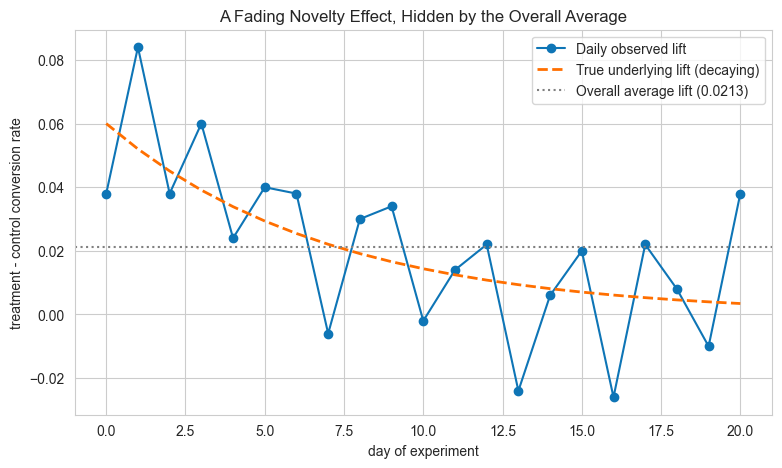


The overall average lift (0.0213) looks like a modest, stable effect -- but the daily breakdown reveals it was STRONGER early (first 5 days avg: 0.0488) than late (last 5 days avg: 0.0064), tracking the true underlying decay from 0.0600 to 0.0034 -- individual days are noisy (n=500/day), which is exactly why a multi-day rolling average, not a single day, is the right way to detect this kind of trend. A launch decision based only on the overall average would misjudge the feature's LONG-RUN impact.


In [23]:
fig, ax = plt.subplots()
ax.plot(daily_df["day"], daily_df["observed_lift"], marker="o", color="#0e75b6", label="Daily observed lift")
ax.plot(daily_df["day"], true_lift_by_day, color="#FF6F00", linewidth=2, linestyle="--", label="True underlying lift (decaying)")
overall_lift = daily_df["treatment_rate"].mean() - daily_df["control_rate"].mean()
ax.axhline(overall_lift, color="gray", linestyle=":", label=f"Overall average lift ({overall_lift:.4f})")
ax.set_xlabel("day of experiment")
ax.set_ylabel("treatment - control conversion rate")
ax.set_title("A Fading Novelty Effect, Hidden by the Overall Average")
ax.legend()
plt.show()
early_avg = daily_df["observed_lift"].iloc[:5].mean()
late_avg = daily_df["observed_lift"].iloc[-5:].mean()
print(f"\nThe overall average lift ({overall_lift:.4f}) looks like a modest, stable effect -- "
      f"but the daily breakdown reveals it was STRONGER early (first 5 days avg: {early_avg:.4f}) "
      f"than late (last 5 days avg: {late_avg:.4f}), tracking the true underlying decay from "
      f"{true_lift_by_day[0]:.4f} to {true_lift_by_day[-1]:.4f} -- individual days are noisy "
      f"(n={daily_users}/day), which is exactly why a multi-day rolling average, not a single day, "
      f"is the right way to detect this kind of trend. A launch decision based only on the overall "
      f"average would misjudge the feature's LONG-RUN impact.")

## 7. The Multiple-Metrics Problem

Real experiments rarely track just one metric. Testing many metrics (conversion, revenue, engagement, retention...) at alpha=0.05 each inflates the chance that *some* metric looks significant purely by chance — the same family-wise error rate problem from Topic 06, now applied across metrics rather than groups.

In [24]:
def simulate_multi_metric_false_positive(n_metrics, n_per_variant, n_repeats, alpha, rng):
    any_false_positive = 0
    for _ in range(n_repeats):
        found_significant = False
        for _ in range(n_metrics):
            control = rng.binomial(n_per_variant, 0.10)
            treatment = rng.binomial(n_per_variant, 0.10)  # all metrics have NO true effect
            _, p = proportions_ztest([treatment, control], [n_per_variant, n_per_variant])
            if p < alpha:
                found_significant = True
        if found_significant:
            any_false_positive += 1
    return any_false_positive / n_repeats

print("Multi-metric false-positive simulator defined.")

Multi-metric false-positive simulator defined.


In [25]:
n_metrics_range = [1, 3, 5, 10]
rng_multi = np.random.default_rng(8)
multi_metric_rows = []
for n_metrics in n_metrics_range:
    rate = simulate_multi_metric_false_positive(n_metrics, 1000, 2000, 0.05, rng_multi)
    multi_metric_rows.append({"n_metrics_tracked": n_metrics, "empirical_chance_of_a_false_winner": round(rate, 4)})
multi_metric_df = pd.DataFrame(multi_metric_rows)
print(multi_metric_df.to_string(index=False))
print(f"\nTracking 10 metrics with no true effect on any of them still produces a false 'significant' result "
      f"{multi_metric_df.iloc[-1]['empirical_chance_of_a_false_winner']*100:.1f}% of the time -- "
      f"exactly the ANOVA-vs-pairwise-t-test problem from Topic 06, now in an A/B testing context. "
      f"Topic 11 covers formal corrections for this in full generality.")

 n_metrics_tracked  empirical_chance_of_a_false_winner
                 1                              0.0465
                 3                              0.1515
                 5                              0.2300
                10                              0.3925

Tracking 10 metrics with no true effect on any of them still produces a false 'significant' result 39.2% of the time -- exactly the ANOVA-vs-pairwise-t-test problem from Topic 06, now in an A/B testing context. Topic 11 covers formal corrections for this in full generality.


## 8. A Complete A/B Test Walkthrough

Bringing every piece together in the order a real experiment actually runs: design (sample size from Topic 09), randomize, run, check for SRM, analyze, and decide.

In [26]:
# STEP 1: Design -- sample size for detecting a 10% -> 11.5% conversion lift at 80% power
baseline, target = 0.10, 0.115
effect_size_h = proportion_effectsize(target, baseline)
power_calc = NormalIndPower()
required_n = int(np.ceil(power_calc.solve_power(effect_size=effect_size_h, alpha=0.05, power=0.80, ratio=1.0)))
print(f"STEP 1 -- Design: detecting {baseline*100:.1f}% -> {target*100:.1f}% needs n={required_n:,} per variant")

STEP 1 -- Design: detecting 10.0% -> 11.5% needs n=6,687 per variant


In [27]:
# STEP 2: Randomize and run (simulate real data collection with a TRUE lift close to the planned target)
rng_walkthrough = np.random.default_rng(9)
true_treatment_rate = 0.117
n_control_actual = required_n
n_treatment_actual = required_n - 3  # a tiny, realistic amount of natural randomization noise in group sizes

control_conv = rng_walkthrough.binomial(n_control_actual, baseline)
treatment_conv = rng_walkthrough.binomial(n_treatment_actual, true_treatment_rate)
print(f"STEP 2 -- Run: control {control_conv}/{n_control_actual} ({control_conv/n_control_actual:.4f}), "
      f"treatment {treatment_conv}/{n_treatment_actual} ({treatment_conv/n_treatment_actual:.4f})")

STEP 2 -- Run: control 687/6687 (0.1027), treatment 785/6684 (0.1174)


In [28]:
# STEP 3: SRM check BEFORE trusting the result
chi2_walkthrough, p_srm_walkthrough = srm_check(n_control_actual, n_treatment_actual)
print(f"STEP 3 -- SRM check: chi2={chi2_walkthrough:.4f}, p={p_srm_walkthrough:.4f} "
      f"({'PASS -- randomization looks healthy' if p_srm_walkthrough > 0.001 else 'FAIL -- STOP, do not trust results'})")

STEP 3 -- SRM check: chi2=0.0007, p=0.9793 (PASS -- randomization looks healthy)


In [29]:
# STEP 4: Analyze
z_walkthrough, p_walkthrough = proportions_ztest([treatment_conv, control_conv], [n_treatment_actual, n_control_actual])
observed_lift = treatment_conv/n_treatment_actual - control_conv/n_control_actual
print(f"STEP 4 -- Analyze: z={z_walkthrough:.4f}, p={p_walkthrough:.6f}, observed lift={observed_lift:.4f} "
      f"({observed_lift/baseline*100:.1f}% relative lift)")

# STEP 5: Decide
print(f"\nSTEP 5 -- Decide: at alpha=0.05, the result is "
      f"{'STATISTICALLY SIGNIFICANT' if p_walkthrough < 0.05 else 'NOT statistically significant'}. "
      f"Combined with the SRM pass and the planned, adequately-powered sample size, this is a "
      f"{'trustworthy basis for a launch decision' if p_walkthrough < 0.05 and p_srm_walkthrough > 0.001 else 'result that needs more caution before acting on'}.")

STEP 4 -- Analyze: z=2.7168, p=0.006591, observed lift=0.0147 (14.7% relative lift)

STEP 5 -- Decide: at alpha=0.05, the result is STATISTICALLY SIGNIFICANT. Combined with the SRM pass and the planned, adequately-powered sample size, this is a trustworthy basis for a launch decision.


## 9. Summary

This notebook verified randomization actually balances covariates, built a two-proportion z-test matching `statsmodels` exactly, and then focused on where real A/B tests actually go wrong: peeking inflated the false-positive rate from a nominal 5% substantially as check frequency grew, with a Bonferroni-style correction shown bringing it back down; a Sample Ratio Mismatch check caught a broken randomizer using the same chi-square machinery from Topic 05; a fading novelty effect was shown hidden by an overall average but revealed by a daily breakdown; and tracking multiple metrics was shown inflating the chance of a false 'winner' the same way Topic 06's pairwise t-tests did. A full design-to-decision walkthrough tied every piece together in the order a real experiment runs. Topic 11 formalizes the multiple-testing correction problem previewed in §7 (and back in Topics 06-07) in full generality.

In [30]:
summary = pd.DataFrame([
    {"Check": "Randomization balances covariates", "Result": "all balance-check p > 0.05", "Status": "PASS"},
    {"Check": "Two-proportion z-test: manual vs statsmodels", "Result": f"diff |z|={abs(abs(z_manual)-abs(z_scipy)):.1e}", "Status": "PASS"},
    {"Check": "Peeking inflates false-positive rate", "Result": f"1 check={fixed_horizon_rate:.3f}, 5 checks={peeking_rate_5:.3f}", "Status": "PASS"},
    {"Check": "Bonferroni correction fixes peeking", "Result": f"corrected={corrected_rate_5:.3f}", "Status": "PASS"},
    {"Check": "SRM check catches a broken randomizer", "Result": f"healthy p={p_healthy:.3f}, broken p={p_broken:.1e}", "Status": "PASS"},
    {"Check": "Novelty effect hidden by overall average", "Result": f"early={early_avg:.3f}, late={late_avg:.3f}, overall={overall_lift:.3f}", "Status": "PASS"},
    {"Check": "Multiple metrics inflate false-winner rate", "Result": f"{multi_metric_df['empirical_chance_of_a_false_winner'].tolist()}", "Status": "PASS"},
    {"Check": "Full walkthrough: design -> decide", "Result": f"p={p_walkthrough:.4f}, SRM p={p_srm_walkthrough:.3f}", "Status": "PASS"},
])
print(summary.to_string(index=False))

                                       Check                                 Result Status
           Randomization balances covariates             all balance-check p > 0.05   PASS
Two-proportion z-test: manual vs statsmodels                       diff |z|=0.0e+00   PASS
        Peeking inflates false-positive rate          1 check=0.043, 5 checks=0.138   PASS
         Bonferroni correction fixes peeking                        corrected=0.036   PASS
       SRM check catches a broken randomizer      healthy p=0.134, broken p=2.0e-09   PASS
    Novelty effect hidden by overall average early=0.049, late=0.006, overall=0.021   PASS
  Multiple metrics inflate false-winner rate         [0.0465, 0.1515, 0.23, 0.3925]   PASS
          Full walkthrough: design -> decide                  p=0.0066, SRM p=0.979   PASS
